In [1]:
# моделирование случайных блужданий
# броуновской частицы
# в ограниченной слева области

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение библиотеки copy
import copy

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt


In [ ]:
# Ячейка № 2

# задание функции, возвращающей
# координаты броуновской частицы,
# совершающей случайные блуждания
# в ограниченной слева области
def Walk_left(x0, X_min, Step, N_step, N_trial, p):
    # x0 - начальная координата
    #      броуновской частицы
    # X_min - координата отражающей стенки
    # Step - значение шага метода Монте-Карло
    # N_Step - длина единичной реализации
    #          метода Монте-Карло
    # N_trial - число независимых испытаний
    #           метода Монте-Карло
    # p - пороговая вероятность

    # инициализация массива, используемого
    # для хранения координат
    # последних точек траекторий
    # броуновской частицы
    X = np.zeros(N_trial + 1)

    # сохранение значения
    # координаты начальной точки
    X[0] = x0

    for i in range(1, N_trial):
        x = x0
        for j in range(N_step):
            # вычисление новой координаты
            # броуновской частицы
            if p >= random.uniform(0, 1):
                x = x - Step
                if x < X_min:
                    # если новая координата меньше X_min,
                    # вычисление координаты
                    # броуновской частицы после
                    # отражения от левой границы
                    x = 2 * X_min - x
            else:
                x = x + Step
        # сохранение значений
        # координат последних точек
        # траектории броуновской частицы
        # на каждом шаге метода Монет-Карло
        X[i] = x

    return X


In [3]:
# Ячейка № 3

# задание функции, возвращающей
# значения плотности распределения
# случайной величины с ограниченной
# областью рассеяния (Zb)
def Pb(x, x0, Sigma, X_bound):
    # x - массив, содержащий
    #     координатную сетку,
    #     в узлах которой вычисляются
    #     значения элементов массивов Zn, Zim, Zb
    # x0 - математическое ожидание порождающего
    #      нормального распределения
    # Sigma - среднеквадратическое отклонение
    #         плотности распределения порождающего
    #         нормального распределения
    # X_max - координата правой границы области рассеяния

    # перемещение в массив X
    # значений элементов
    # массива х
    X = copy.copy(x)
    Np = len(X)

    # инициализация массива Zb
    Zb = np.zeros(Np)

    # вычисление плотностей распределения
    # случайной величины с ограниченной справа
    # областью рассеяния (Zb)
    # в соответствие с (12.59), (12.60)
    for i in range(Np):
        Zn = (
            1
            / (np.sqrt(2 * np.pi) * Sigma)
            * np.exp(-((X[i] - x0) ** 2) / (2 * Sigma**2))
        )
        Zim = (
            1
            / (np.sqrt(2 * np.pi) * Sigma)
            * np.exp(-((X[i] + x0 - 2 * X_bound) ** 2) / (2 * Sigma**2))
        )
        Zb[i] = Zn + Zim

    return Zb

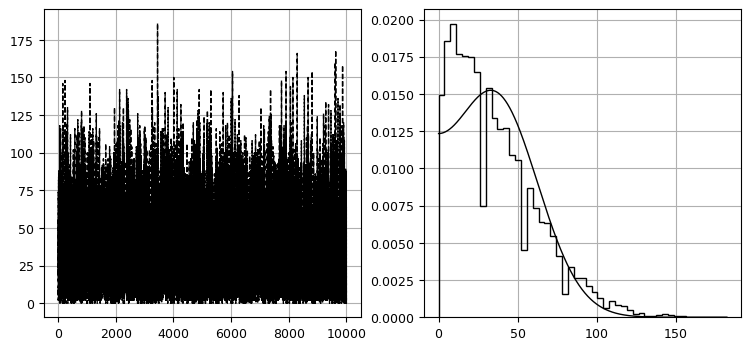

In [ ]:
# Ячейка № 4

# инициализация генератора случайных чисел
random.seed()

# вычисление и визуализация
# случайной последовательности,
# составленной из значений
# координат точек, в которых
# оказывалась броуновская частица,
# стартовавшая из одной и той же
# начальной точки и совершавшая N_step шагов,
# ее гистограммы и соответствующей теоретической
# плотности распределения

# задание числа шагов
# броуновской частицы
N_step = 2 * 10**3

# задание числа испытаний
# метода Монте-Карло
N_trial = 1 * 10**4

# задание граничного значения
# вероятности смещения
p = 0.5

# задание начального положения
# броуновской частицы
x0 = 6

# задание координаты
# отражающей стенки
X_min = 0

# задание значения
# шага броуновской частицы
Step = 1

# вычисление ансамбля координат
# броуновской частицы, совершающей
# случайные блуждания в ограниченной слева области
M_left = Walk_left(x0, X_min, Step, N_step, N_trial, p)

# задание значений интервалов гистограммы
N_bin = 50
xbins = np.arange(np.min(M_left), np.max(M_left), (max(M_left) - min(M_left)) / N_bin)

# вычисление среднего значения
# ансамбля координат случайных
# блужданий
M_mean = np.mean(M_left)

# вычисление дисперсии
# ансамбля координат случайных
# блужданий
M_std = np.std(M_left)

# вычисление координат узлов сетки,
# используемой для вычисления
# плотности распределения случайной величины
# с ограниченной областью рассеяния
x = np.linspace(np.min(xbins), np.max(xbins), 10**3)

# вычисление значений
# плотности распределения
# случайной величины с
# ограниченной справа
# областью рассеяния
dP_left = Pb(x, M_mean, M_std, X_min)

# визуализация сгенерированной
# случайной последовательности,
# ее гистограммы и плотности
# распределения
fig = plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
# визуализация ансамбля
# координат случайных
# блужданий
plt.plot(M_left, "--k", lw=1)
plt.grid(True)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.subplot(1, 2, 2)
# визуализация гистограммы
# ансамбля координат
# случайных блужданий
plt.hist(M_left, bins=xbins, histtype="step", color="black", density=True)

# визуализация плотности
# распределения случайной
# величины с ограниченной слева
# областью рассеяния

plt.plot(x, dP_left, "-k", lw=1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.grid(True)

plt.show()